### These 1: Entwicklungsländer wurden von Covid-19 stärker betroffen als Industrieländer

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Data_Files\\base_data104_with_lookup.csv')

# Filter data for the year 2020 - 2025
df_2020_2025 = df[(df['Year'] >= 2020) & (df['Year'] <= 2025)]

# Filter für COVID-19-bezogene Einträge
covid_filter = df_2020_2025[df_2020_2025['Cause'].str.contains('COVID-19, virus identified', case=False, na=False)]

# list all unique countries in the dataset
unique_countries = covid_filter['Country'].unique()

print("Unique countries with COVID-19 related entries from 2020 to 2025:")
for country in unique_countries:
    print(country)





Unique countries with COVID-19 related entries from 2020 to 2025:
Mauritius
Mayotte
Morocco
Reunion
Tunisia
Argentina
Aruba
Brazil
Canada
Chile
Colombia
Costa Rica
Cuba
Ecuador
French Guiana
Guadeloupe
Guatemala
Martinique
Mexico
Nicaragua
Paraguay
Peru
United States of America
Uruguay
Hong Kong SAR
Israel
Maldives
Mongolia
Oman
Republic of Korea
Singapore
United Arab Emirates
Armenia
Austria
Belgium
Bulgaria
Croatia
Estonia
Georgia
Greece
Iceland
Kazakhstan
Latvia
Luxembourg
Malta
Spain
Switzerland
United Kingdom
United Kingdom, England and Wales
United Kingdom, Northern Ireland
United Kingdom, Scotland
Poland
Slovakia
Cyprus
Japan
Lebanon
Czech Republic
Denmark
France
Germany
Hungary
Italy
Lithuania
Netherlands
Sweden
Australia
Antigua and Barbuda
Grenada
Panama
Puerto Rico
Virgin Islands (USA)
Saudi Arabia
Republic of Moldova
Botswana
Portugal
Qatar
Thailand
Occupied Palestinian Territory
Kuwait


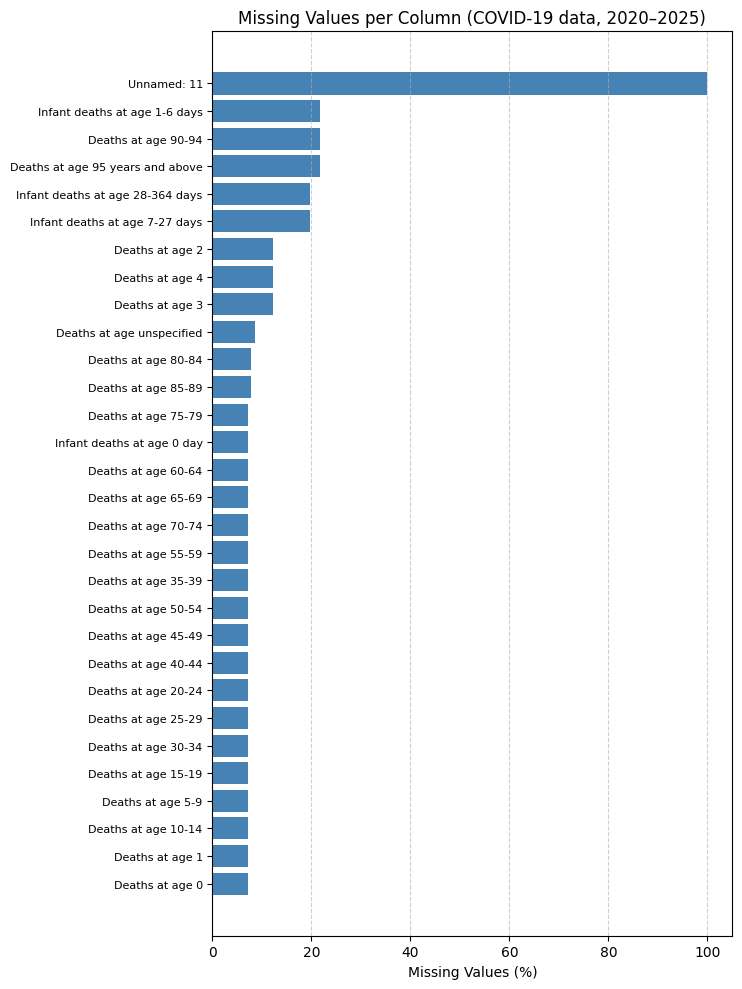

In [14]:
## Missig values analysieren
# Sortierte, besser lesbare Missing Values Grafik
missing_values = covid_filter.isnull().sum()
missing_percent = (missing_values / len(covid_filter)) * 100

# Nur Spalten mit fehlenden Werten anzeigen
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=True)

plt.figure(figsize=(8, 10))
plt.barh(missing_percent.index, missing_percent, color='steelblue')
plt.xlabel('Missing Values (%)')
plt.title('Missing Values per Column (COVID-19 data, 2020–2025)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Kürzere Achsenbeschriftung für lange Spaltennamen
plt.yticks(fontsize=8)

plt.show()


### We need to define developing and industrialized countries first.
### this will be done by calculating the median of the last 5 years of bipc per capita
### countries below 20000 USD will be defined as developing countries

In [53]:
from wbgapi import data as wb_data

countries = ['Mexico', 'Colombia', 'Brazil', 'Switzerland', 'Japan', 'United States of America', 'United Kingdom', 'Italy', 'Ecuador']
country_codes = ['MEX', 'COL', 'BRA', 'CHE', 'JPN', 'USA', 'GBR', 'ITA', 'ECU']

countriesdict = dict(zip(countries, country_codes))

average_gdp = {}

for i in range(len(countries)):
    gdp = wb_data.DataFrame('NY.GDP.PCAP.CD', economy=country_codes[i], time=range(2020, 2026))
    print(gdp)
    # Mittelwert über alle Jahre berechnen (Zeile enthält die Werte)
    avg = gdp.iloc[0].median()
    average_gdp[countries[i]] = float(avg)

print(average_gdp)

# Define lists of developing and industrialized countries
developing_countries = {}
industrialized_countries = {}


for country, gdp in average_gdp.items():
    code = countriesdict[country]
    if gdp < 20000:
        developing_countries[country] = code
        print(f"{country} is a developing country ({code}) with GDP per capita of {gdp:.2f} USD.")
    else:
        industrialized_countries[country] = code
        print(f"{country} is an industrialized country ({code}) with GDP per capita of {gdp:.2f} USD.")

print("\nDeveloping countries dictionary:")
print(developing_countries)

print("\nIndustrialized countries dictionary:")
print(industrialized_countries)







              YR2020        YR2021        YR2022        YR2023        YR2024
economy                                                                     
MEX      8841.270751  10314.050673  11402.141037  13826.130657  14157.944584
              YR2020       YR2021       YR2022       YR2023       YR2024
economy                                                                 
COL      5339.687114  6222.621644  6680.445069  7000.836605  7913.988015
              YR2020      YR2021       YR2022        YR2023        YR2024
economy                                                                  
BRA      7074.193783  7972.53665  9281.333344  10377.589279  10280.314862
               YR2020       YR2021       YR2022         YR2023         YR2024
economy                                                                      
CHE      85897.784334  93664.77367  94394.51068  100631.802755  103669.872008
               YR2020       YR2021        YR2022        YR2023        YR2024
economy          

In [54]:
columns_to_display = ['Country', 'Year', 'Cause', 'Sex', 'Deaths at all ages',]


# Jetzt pro Land filtern
for country in developing_countries:
    country_data = covid_filter[covid_filter['Country'] == country][columns_to_display]
    print(f"--- {country} ---")
    print(country_data.to_string(), "\n")

for country in industrialized_countries:
    country_data = covid_filter[covid_filter['Country'] == country][columns_to_display]
    print(f"--- {country} ---")
    print(country_data.to_string(), "\n")

--- Mexico ---
        Country  Year                       Cause  Sex  Deaths at all ages
3764589  Mexico  2020  COVID-19, virus identified    1               93698
3764590  Mexico  2020  COVID-19, virus identified    2               53132
3764591  Mexico  2020  COVID-19, virus identified    9                   4
4405606  Mexico  2021  COVID-19, virus identified    1              107435
4405607  Mexico  2021  COVID-19, virus identified    2               70743
4405608  Mexico  2021  COVID-19, virus identified    9                   2
4550242  Mexico  2022  COVID-19, virus identified    1               19051
4550243  Mexico  2022  COVID-19, virus identified    2               12737
4550244  Mexico  2022  COVID-19, virus identified    9                   1 

--- Colombia ---
          Country  Year                       Cause  Sex  Deaths at all ages
3673518  Colombia  2020  COVID-19, virus identified    1               29545
3673519  Colombia  2020  COVID-19, virus identified    2      

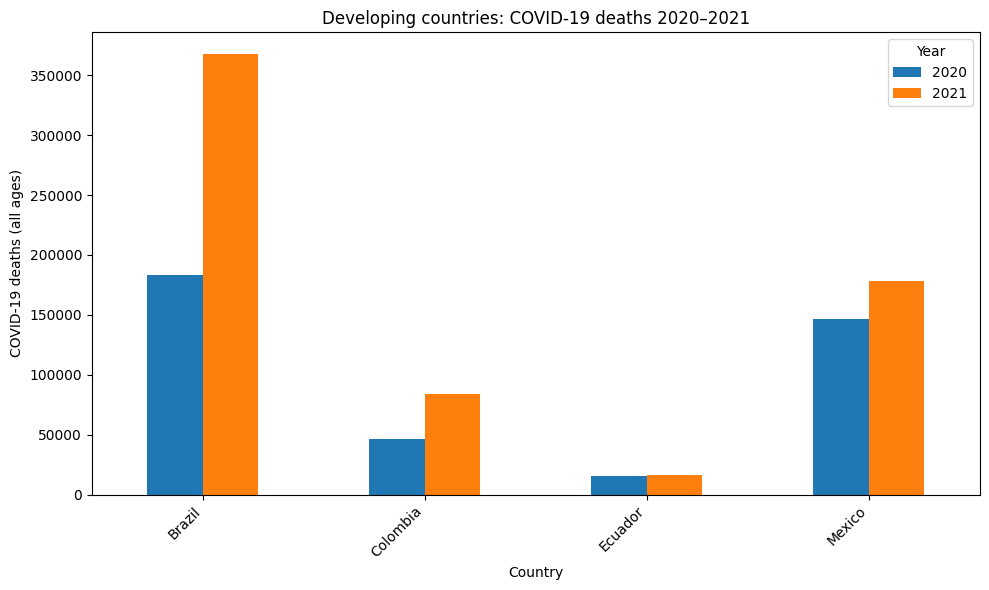

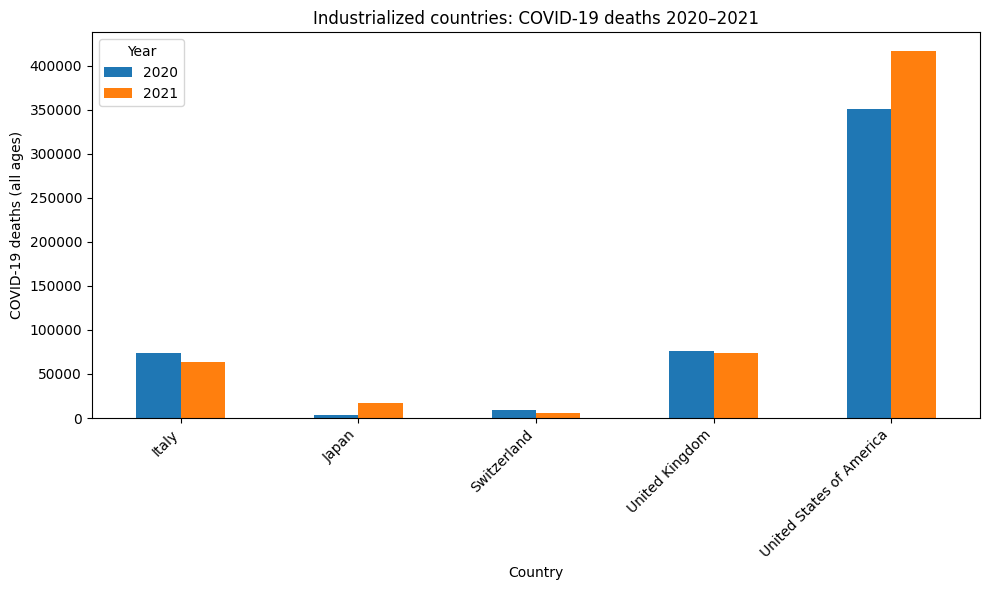

In [55]:
# Filter to 2020–2021
covid_20_21 = covid_filter[(covid_filter['Year'] >= 2020) & (covid_filter['Year'] <= 2021)]

# Sum deaths per country and year
agg = (
    covid_20_21
    .groupby(['Country', 'Year'])['Deaths at all ages']
    .sum()
    .reset_index()
)



# Plot grouped bar chart separately for each group
def plot_grouped_bar(countries_list, title):
    subset = agg[agg['Country'].isin(countries_list.keys())]
    if subset.empty:
        print(f"No data available for {title}.")
        return
    pivot = subset.pivot(index='Country', columns='Year', values='Deaths at all ages')
    pivot.plot(kind='bar', figsize=(10, 6))
    plt.ylabel('COVID-19 deaths (all ages)')
    plt.title(f'{title}: COVID-19 deaths 2020–2021')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Developing countries
plot_grouped_bar(developing_countries, "Developing countries")

# Industrialized countries
plot_grouped_bar(industrialized_countries, "Industrialized countries")


Mexico: 128613117 inhabitants
Colombia: 51737944 inhabitants
Brazil: 210306415 inhabitants
Ecuador: 17823897 inhabitants

Average populations: {'Mexico': 128613117, 'Colombia': 51737944, 'Brazil': 210306415, 'Ecuador': 17823897}
Switzerland: 8777088 inhabitants
Japan: 125124989 inhabitants
United States of America: 334017321 inhabitants
United Kingdom: 67604000 inhabitants
Italy: 59013667 inhabitants

Average populations: {'Switzerland': 8777088, 'Japan': 125124989, 'United States of America': 334017321, 'United Kingdom': 67604000, 'Italy': 59013667}


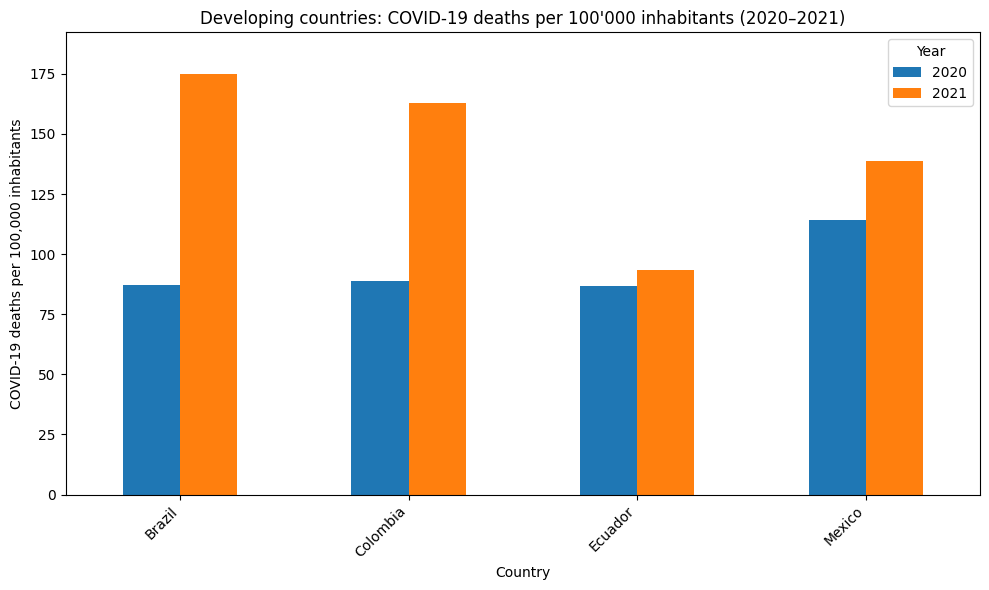

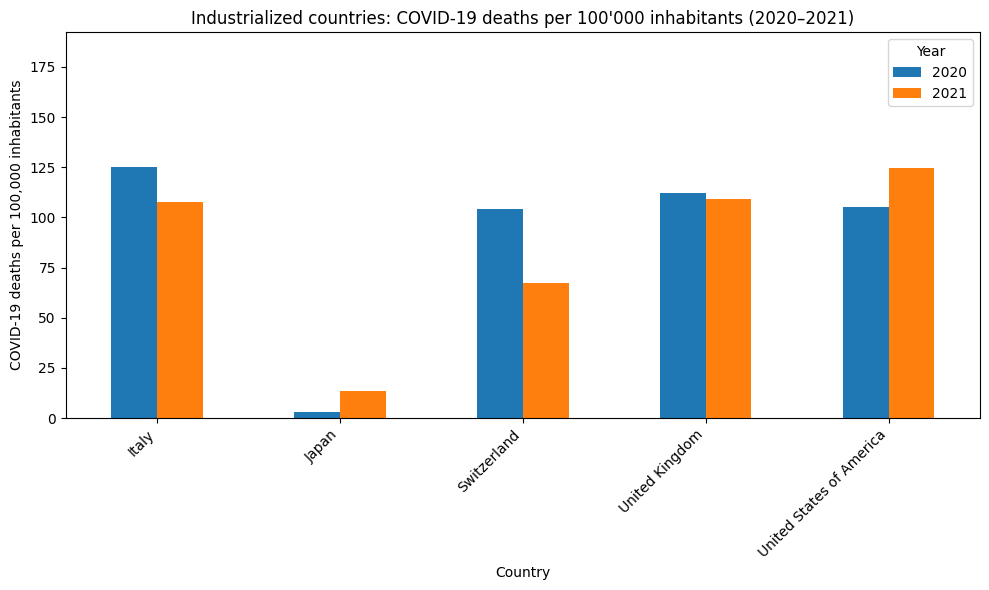

In [56]:
def get_inhabitants(countriesdict):
    inhabitants_countries = {}
    for country, code in countriesdict.items():
        pop_data = wb_data.DataFrame('SP.POP.TOTL', economy=code, time=range(2020, 2026))
        avg_pop = pop_data.iloc[0].median()
        inhabitants_countries[country] = int(avg_pop)
        print(f"{country}: {int(avg_pop)} inhabitants")
    print("\nAverage populations:", inhabitants_countries)
    return inhabitants_countries


# Bevölkerungsdaten für beide Gruppen holen
inhabitants_developing = get_inhabitants(developing_countries)
inhabitants_industrialized = get_inhabitants(industrialized_countries)


# ---- Hilfsfunktion: berechnet Deaths per 100k ----
def get_normalized_data(countriesdict, inhabitants_dict):
    subset = agg[agg['Country'].isin(countriesdict.keys())].copy()
    if subset.empty:
        return None
    subset['Deaths per 100k'] = subset.apply(
        lambda row: (row['Deaths at all ages'] / inhabitants_dict.get(row['Country'], 1)) * 100000,
        axis=1
    )
    return subset


# Normalisierte Daten für beide Gruppen berechnen
subset_dev = get_normalized_data(developing_countries, inhabitants_developing)
subset_ind = get_normalized_data(industrialized_countries, inhabitants_industrialized)

# Maximalwert bestimmen, um gleiche Skala zu setzen
max_y = max(subset_dev['Deaths per 100k'].max(), subset_ind['Deaths per 100k'].max())


# ---- Plotfunktion mit gemeinsamer Skala ----
def plot_normalized_fixed_scale(subset, title, max_y):
    if subset is None or subset.empty:
        print(f"No data available for {title}.")
        return
    pivot = subset.pivot(index='Country', columns='Year', values='Deaths per 100k')
    ax = pivot.plot(kind='bar', figsize=(10, 6))
    ax.set_ylabel('COVID-19 deaths per 100,000 inhabitants')
    ax.set_title(f"{title}: COVID-19 deaths per 100'000 inhabitants (2020–2021)")
    ax.set_ylim(0, max_y * 1.1)  # gleiche Skala mit etwas Puffer (10 %)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# ---- Plotten ----
plot_normalized_fixed_scale(subset_dev, "Developing countries", max_y)
plot_normalized_fixed_scale(subset_ind, "Industrialized countries", max_y)
